# KDB Family — Complete Limited-Pass Benchmark

This is the **single self-contained notebook** for the new primary benchmark. It defines every methodology once and reuses it for Skin Segmentation and MiniBooNE—there is no duplicated learner code and no dependency on project-specific Python modules.

It contains the existing in-memory MDL preprocessing; arbitrary-k KDB and true one-pass NB; published sKDB; weighted-BN dKDB; experimental/unpublished sdKDB; one multiclass evaluator; all requested tests; both smoke datasets; and all inline plots.

The existing RF/XGB/HT notebooks remain separate and are deliberately excluded. Large experiments are not run by default.

## 1. Methodological contract and Fupla interpretation

The implementation follows [Zaidi's Fupla repository](https://github.com/nayyarzaidi/fupla): structure statistics, KDB parameters, selective KDB, then the discriminative stage.

- **sKDB:** third-pass incremental leave-one-out evaluation of every `k <= kmax` after every MI-ordered feature prefix, minimizing `sqrt(mean((1-p_true)^2))`.
- **dKDB:** learn generative log-probabilities Θ, hold Θ fixed, then learn separate weighted-BN parameters with streaming SGD or AdaGrad. This is not generic logistic regression.
- **sdKDB:** **experimental/unpublished**. It is exactly published sKDB selection followed by the same dKDB weighting stage, matching Fupla's `-S` then `-D` order. No extra stage is invented.
- Fupla's uniform-prior m-estimate uses `m=1`. Discriminative weights start at zero; zero discriminative passes bypass weighting and recover the generative model exactly.

### Learner pass rules

| Learner | Full learner passes | Rows for training-fold size N |
|---|---:|---:|
| KDB(k=0) / NB | 1 | N |
| KDB(k>0) | 2 | 2N |
| sKDB | 3 | 3N |
| dKDB | base KDB passes + D | `(base + D)N` |
| experimental sdKDB | 3 + D | `(3 + D)N` |

Preprocessing is fitted separately on each training fold and is not a learner pass.

## 2. Imports and display settings

In [1]:
from __future__ import annotations

import json
import pickle
import sys
from collections.abc import Callable, Iterator, Mapping, Sequence
from contextlib import contextmanager
from dataclasses import asdict, dataclass
from hashlib import sha256
from math import log2
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.datasets import fetch_openml
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)


## 3. Shared in-memory MDL preprocessing

This retains the existing supervised Fayyad–Irani-style approach and is intentionally not made out of core. A fresh discretizer is fitted only on each CV training fold. NaN and infinite values receive a reserved state.

In [2]:
def _entropy(counts: np.ndarray) -> float:
    total = int(counts.sum())
    if total == 0:
        return 0.0
    probabilities = counts[counts > 0] / total
    return float(-np.sum(probabilities * np.log2(probabilities)))


def _mdl_cut_points(values: np.ndarray, labels: np.ndarray) -> np.ndarray:
    """Return recursively accepted Fayyad-Irani MDL cuts for one feature."""

    if values.size < 2 or np.unique(labels).size < 2:
        return np.empty(0, dtype=np.float64)

    order = np.argsort(values, kind="mergesort")
    sorted_values = values[order]
    sorted_labels = labels[order]
    n_classes = int(sorted_labels.max()) + 1
    accepted: list[float] = []

    def split(start: int, stop: int) -> None:
        n = stop - start
        if n < 2:
            return

        node_labels = sorted_labels[start:stop]
        total_counts = np.bincount(node_labels, minlength=n_classes)
        parent_entropy = _entropy(total_counts)
        if parent_entropy == 0.0:
            return

        left_counts = np.zeros(n_classes, dtype=np.int64)
        best_position: int | None = None
        best_weighted_entropy = np.inf
        for position in range(start, stop - 1):
            left_counts[sorted_labels[position]] += 1
            if sorted_values[position] == sorted_values[position + 1]:
                continue
            n_left = position - start + 1
            n_right = n - n_left
            right_counts = total_counts - left_counts
            weighted = (
                n_left * _entropy(left_counts)
                + n_right * _entropy(right_counts)
            ) / n
            if weighted < best_weighted_entropy:
                best_weighted_entropy = weighted
                best_position = position

        if best_position is None:
            return

        left = np.bincount(
            sorted_labels[start : best_position + 1], minlength=n_classes
        )
        right = total_counts - left
        gain = parent_entropy - best_weighted_entropy
        k = int(np.count_nonzero(total_counts))
        k_left = int(np.count_nonzero(left))
        k_right = int(np.count_nonzero(right))
        delta = log2((3**k) - 2) - (
            k * parent_entropy
            - k_left * _entropy(left)
            - k_right * _entropy(right)
        )
        threshold = (log2(n - 1) + delta) / n
        if gain <= threshold:
            return

        low = float(sorted_values[best_position])
        high = float(sorted_values[best_position + 1])
        accepted.append(low + (high - low) / 2.0)
        split(start, best_position + 1)
        split(best_position + 1, stop)

    split(0, sorted_values.size)
    return np.asarray(sorted(accepted), dtype=np.float64)


class MDLDiscretizer:
    """Training-fold-only, in-memory supervised MDL discretizer.

    A permanently reserved state handles NaN and +/- infinity.  The public fit
    audit fields are used by the evaluator and leakage tests.
    """

    method_name = "Fayyad-Irani supervised MDL (in memory; training fold only)"

    def __init__(self) -> None:
        self.cut_points_: list[np.ndarray] | None = None
        self.cardinalities_: np.ndarray | None = None
        self.fit_seconds_: float = 0.0
        self.fit_rows_: int = 0
        self.fit_calls_: int = 0

    def fit(self, X: Sequence, y: Sequence) -> "MDLDiscretizer":
        started = perf_counter()
        X_array = _numeric_matrix(X)
        y_array = np.asarray(y, dtype=object).reshape(-1)
        if len(X_array) != len(y_array):
            raise ValueError("X and y must contain the same number of rows")
        if len(X_array) == 0:
            raise ValueError("Cannot fit MDLDiscretizer on an empty fold")

        label_to_index: dict[object, int] = {}
        encoded_y = np.empty(len(y_array), dtype=np.int32)
        for row, label in enumerate(y_array.tolist()):
            try:
                encoded_y[row] = label_to_index[label]
            except KeyError:
                label_to_index[label] = len(label_to_index)
                encoded_y[row] = label_to_index[label]

        self.cut_points_ = []
        for feature in range(X_array.shape[1]):
            observed = np.isfinite(X_array[:, feature])
            self.cut_points_.append(
                _mdl_cut_points(
                    X_array[observed, feature], encoded_y[observed]
                )
            )

        # digitize yields len(cuts)+1 observed bins; reserve one more for missing.
        self.cardinalities_ = np.asarray(
            [len(cuts) + 2 for cuts in self.cut_points_], dtype=np.int32
        )
        self.fit_rows_ = int(len(X_array))
        self.fit_calls_ += 1
        self.fit_seconds_ = float(perf_counter() - started)
        return self

    def transform(self, X: Sequence) -> np.ndarray:
        if self.cut_points_ is None or self.cardinalities_ is None:
            raise RuntimeError("MDLDiscretizer must be fitted before transform")
        X_array = _numeric_matrix(X)
        if X_array.shape[1] != len(self.cut_points_):
            raise ValueError("Transform data has a different feature count")

        transformed = np.empty(X_array.shape, dtype=np.int32)
        for feature, cuts in enumerate(self.cut_points_):
            observed = np.isfinite(X_array[:, feature])
            transformed[observed, feature] = np.digitize(
                X_array[observed, feature], cuts, right=False
            )
            transformed[~observed, feature] = len(cuts) + 1
        return transformed

    def fit_transform(self, X: Sequence, y: Sequence) -> np.ndarray:
        return self.fit(X, y).transform(X)


def _numeric_matrix(X: Sequence) -> np.ndarray:
    if hasattr(X, "to_numpy"):
        X = X.to_numpy(copy=False)
    array = np.asarray(X)
    if array.ndim != 2:
        raise ValueError("X must be a two-dimensional matrix")
    try:
        return array.astype(np.float64, copy=False)
    except (TypeError, ValueError) as exc:
        raise TypeError("MDLDiscretizer requires numeric features") from exc


## 4. Auditable learner passes

Each declared pass must consume every training row exactly once. Records contain the stage, pass number, rows processed and elapsed seconds.

In [3]:
@dataclass(frozen=True)
class PassRecord:
    stage: str
    pass_number: int
    rows_processed: int
    seconds: float


class PassTracker:
    """Records only full learner traversals (preprocessing is separate)."""

    def __init__(self, expected_rows: int) -> None:
        if expected_rows <= 0:
            raise ValueError("expected_rows must be positive")
        self.expected_rows = int(expected_rows)
        self.records: list[PassRecord] = []

    @contextmanager
    def iter_rows(
        self, stage: str, X: np.ndarray, y: np.ndarray
    ) -> Iterator[Iterator[tuple[np.ndarray, int]]]:
        processed = 0
        started = perf_counter()

        def rows() -> Iterator[tuple[np.ndarray, int]]:
            nonlocal processed
            for index in range(self.expected_rows):
                processed += 1
                yield X[index], int(y[index])

        yield rows()
        if processed != self.expected_rows:
            raise RuntimeError(
                f"{stage} processed {processed} rows; expected "
                f"{self.expected_rows}"
            )
        self.records.append(
            PassRecord(
                stage=stage,
                pass_number=len(self.records) + 1,
                rows_processed=processed,
                seconds=float(perf_counter() - started),
            )
        )

    @contextmanager
    def iter_batches(
        self,
        stage: str,
        X: np.ndarray,
        y: np.ndarray,
        batch_size: int,
    ) -> Iterator[Iterator[tuple[np.ndarray, np.ndarray]]]:
        processed = 0
        started = perf_counter()

        def batches() -> Iterator[tuple[np.ndarray, np.ndarray]]:
            nonlocal processed
            for start in range(0, self.expected_rows, batch_size):
                stop = min(start + batch_size, self.expected_rows)
                processed += stop - start
                yield X[start:stop], y[start:stop]

        yield batches()
        if processed != self.expected_rows:
            raise RuntimeError(
                f"{stage} processed {processed} rows; expected "
                f"{self.expected_rows}"
            )
        self.records.append(
            PassRecord(
                stage=stage,
                pass_number=len(self.records) + 1,
                rows_processed=processed,
                seconds=float(perf_counter() - started),
            )
        )

    @property
    def pass_count(self) -> int:
        return len(self.records)

    @property
    def rows_processed(self) -> int:
        return int(sum(record.rows_processed for record in self.records))

    def as_records(self) -> list[dict[str, object]]:
        return [asdict(record) for record in self.records]


## 5. KDB: arbitrary k and true one-pass k=0

For `k>0`, pass 1 learns MI/CMI structure and pass 2 estimates conditional tables. For `k=0`, structure learning and pair-count allocation are skipped completely and NB parameters are learned in one traversal.

In [4]:
class KDBClassifier:
    """K-dependence Bayesian classifier for discrete, non-negative features.

    ``k=0`` is a genuine one-pass Naive Bayes path: it skips MI, CMI and all
    pair-count allocation.  ``k>0`` uses one structure pass and one parameter
    pass, as in Fupla's KDB stages.
    """

    model_name = "KDB"

    def __init__(self, k: int = 1, *, m_estimate: float = 1.0) -> None:
        if int(k) != k or k < 0:
            raise ValueError("k must be a non-negative integer")
        if m_estimate <= 0:
            raise ValueError("m_estimate must be positive")
        self.k = int(k)
        self.m_estimate = float(m_estimate)

    def fit(self, X: Sequence, y: Sequence) -> "KDBClassifier":
        X_array = _categorical_matrix(X)
        y_encoded, classes, label_to_index = _encode_labels(y)
        if len(X_array) != len(y_encoded):
            raise ValueError("X and y must contain the same number of rows")
        if len(X_array) == 0 or X_array.shape[1] == 0:
            raise ValueError("KDB requires at least one row and one feature")

        self.classes_ = classes
        self._label_to_index_ = label_to_index
        self.n_classes_ = len(classes)
        self.n_features_in_ = X_array.shape[1]
        self.n_train_rows_ = len(X_array)
        self.cardinalities_ = X_array.max(axis=0).astype(np.int64) + 1
        self.pass_tracker_ = PassTracker(len(X_array))
        self.structure_learned_ = self.k > 0
        self.selection_rmse_ = None
        self.selected_k_ = min(self.k, self.n_features_in_ - 1)
        self.selected_feature_count_ = self.n_features_in_
        self.discriminative_iterations_ = 0
        self.discriminative_updates_ = 0

        if self.k == 0:
            self.feature_order_ = np.arange(self.n_features_in_, dtype=np.int64)
            self.parents_ = [np.empty(0, dtype=np.int64) for _ in self.feature_order_]
            self.class_counts_ = np.zeros(self.n_classes_, dtype=np.int64)
            self.tables_ = [
                [
                    {
                        (): np.zeros(
                            (int(self.cardinalities_[feature]), self.n_classes_),
                            dtype=np.int64,
                        )
                    }
                ]
                for feature in self.feature_order_
            ]
            with self.pass_tracker_.iter_rows(
                "naive_bayes_parameters", X_array, y_encoded
            ) as rows:
                for row, target in rows:
                    self.class_counts_[target] += 1
                    for position, feature in enumerate(self.feature_order_):
                        self.tables_[position][0][()][int(row[feature]), target] += 1
        else:
            self._fit_structure(X_array, y_encoded)
            self._fit_parameters(X_array, y_encoded)

        self.full_feature_order_ = self.feature_order_.copy()
        self.training_seconds_ = float(
            sum(record.seconds for record in self.pass_tracker_.records)
        )
        return self

    def _fit_structure(self, X: np.ndarray, y: np.ndarray) -> None:
        n_features = self.n_features_in_
        n_classes = self.n_classes_
        xy_offsets = np.zeros(n_features, dtype=np.int64)
        if n_features > 1:
            xy_offsets[1:] = np.cumsum(self.cardinalities_[:-1])
        xy_counts = np.zeros(
            (int(self.cardinalities_.sum()), n_classes), dtype=np.int64
        )
        class_counts = np.zeros(n_classes, dtype=np.int64)

        pair_i: list[int] = []
        pair_j: list[int] = []
        pair_offsets: list[int] = []
        pair_state_total = 0
        for i in range(1, n_features):
            for j in range(i):
                pair_i.append(i)
                pair_j.append(j)
                pair_offsets.append(pair_state_total)
                pair_state_total += int(self.cardinalities_[i] * self.cardinalities_[j])
        pair_i_array = np.asarray(pair_i, dtype=np.int64)
        pair_j_array = np.asarray(pair_j, dtype=np.int64)
        pair_offsets_array = np.asarray(pair_offsets, dtype=np.int64)
        pair_counts = np.zeros((pair_state_total, n_classes), dtype=np.int64)

        n_pairs = max(1, len(pair_i))
        batch_size = max(1, min(512, 1_000_000 // n_pairs))
        with self.pass_tracker_.iter_batches(
            "kdb_structure_mi_cmi", X, y, batch_size
        ) as batches:
            for X_batch, y_batch in batches:
                np.add.at(class_counts, y_batch, 1)
                xy_states = xy_offsets[None, :] + X_batch
                for class_index in range(n_classes):
                    mask = y_batch == class_index
                    if np.any(mask):
                        np.add.at(
                            xy_counts[:, class_index],
                            xy_states[mask].ravel(),
                            1,
                        )
                if pair_i:
                    pair_states = (
                        pair_offsets_array[None, :]
                        + X_batch[:, pair_i_array]
                        * self.cardinalities_[pair_j_array][None, :]
                        + X_batch[:, pair_j_array]
                    )
                    for class_index in range(n_classes):
                        mask = y_batch == class_index
                        if np.any(mask):
                            np.add.at(
                                pair_counts[:, class_index],
                                pair_states[mask].ravel(),
                                1,
                            )

        xy_by_feature = [
            xy_counts[
                int(xy_offsets[f]) : int(xy_offsets[f] + self.cardinalities_[f])
            ]
            for f in range(n_features)
        ]
        total = float(len(X))
        mi = np.zeros(n_features, dtype=np.float64)
        for feature, counts in enumerate(xy_by_feature):
            value_counts = counts.sum(axis=1)
            denominator = value_counts[:, None] * class_counts[None, :]
            mask = counts > 0
            mi[feature] = np.sum(
                (counts[mask] / total)
                * np.log2((counts[mask] * total) / denominator[mask])
            )

        cmi = np.zeros((n_features, n_features), dtype=np.float64)
        pair_lookup: dict[tuple[int, int], int] = {}
        for pair_index, (i, j, offset) in enumerate(
            zip(pair_i, pair_j, pair_offsets)
        ):
            pair_lookup[(i, j)] = pair_index
            size = int(self.cardinalities_[i] * self.cardinalities_[j])
            counts = pair_counts[offset : offset + size].reshape(
                int(self.cardinalities_[i]),
                int(self.cardinalities_[j]),
                n_classes,
            )
            denominator = (
                xy_by_feature[i][:, None, :] * xy_by_feature[j][None, :, :]
            )
            class_numerator = counts * class_counts[None, None, :]
            mask = counts > 0
            score = np.sum(
                (counts[mask] / total)
                * np.log2(class_numerator[mask] / denominator[mask])
            )
            cmi[i, j] = cmi[j, i] = score

        self.feature_mi_ = mi
        self.feature_order_ = np.argsort(-mi, kind="mergesort").astype(np.int64)
        self.parents_ = []
        for position, feature in enumerate(self.feature_order_):
            parent_count = min(position, self.k)
            if parent_count == 0:
                self.parents_.append(np.empty(0, dtype=np.int64))
                continue
            candidates = self.feature_order_[:position]
            candidate_scores = cmi[int(feature), candidates]
            ranking = np.argsort(-candidate_scores, kind="mergesort")
            self.parents_.append(candidates[ranking[:parent_count]].copy())

        # Structure statistics are intentionally local: they are not model state.

    def _fit_parameters(self, X: np.ndarray, y: np.ndarray) -> None:
        self.class_counts_ = np.zeros(self.n_classes_, dtype=np.int64)
        self.tables_: list[list[dict[tuple[int, ...], np.ndarray]]] = []
        for position, feature in enumerate(self.feature_order_):
            self.tables_.append([{} for _ in range(len(self.parents_[position]) + 1)])

        with self.pass_tracker_.iter_rows("kdb_parameters", X, y) as rows:
            for row, target in rows:
                self.class_counts_[target] += 1
                for position, feature in enumerate(self.feature_order_):
                    x_value = int(row[feature])
                    parents = self.parents_[position]
                    for depth in range(len(parents) + 1):
                        context = tuple(int(row[p]) for p in parents[:depth])
                        table = self.tables_[position][depth].get(context)
                        if table is None:
                            table = np.zeros(
                                (int(self.cardinalities_[feature]), self.n_classes_),
                                dtype=np.int64,
                            )
                            self.tables_[position][depth][context] = table
                        table[x_value, target] += 1

    @property
    def learner_passes_(self) -> int:
        return self.pass_tracker_.pass_count

    @property
    def learner_rows_processed_(self) -> int:
        return self.pass_tracker_.rows_processed

    @property
    def selected_feature_indices_(self) -> np.ndarray:
        return self.feature_order_[: self.selected_feature_count_].copy()

    def pass_records(self) -> list[dict[str, object]]:
        return self.pass_tracker_.as_records()

    def model_state_bytes(self) -> int:
        return _deep_sizeof(self)

    def predict_proba(self, X: Sequence) -> np.ndarray:
        self._require_fitted()
        X_array = _categorical_matrix(X)
        if X_array.shape[1] != self.n_features_in_:
            raise ValueError("Prediction data has a different feature count")
        probabilities = np.empty((len(X_array), self.n_classes_), dtype=np.float64)
        for row_index, row in enumerate(X_array):
            probabilities[row_index] = _softmax(self._generative_log_scores(row))
        return probabilities

    def predict(self, X: Sequence) -> np.ndarray:
        probabilities = self.predict_proba(X)
        return self.classes_[np.argmax(probabilities, axis=1)]

    def _generative_log_scores(self, row: np.ndarray) -> np.ndarray:
        scores = self._class_log_theta()
        for position in range(self.selected_feature_count_):
            feature = int(self.feature_order_[position])
            table, _, _ = self._lookup_table(row, position, self.selected_k_)
            scores += self._conditional_log_theta(table, int(row[feature]))
        return scores

    def _class_log_theta(self) -> np.ndarray:
        m = self.m_estimate
        return np.log(
            (self.class_counts_ + m / self.n_classes_)
            / (self.n_train_rows_ + m)
        )

    def _conditional_log_theta(
        self, table: np.ndarray, value: int
    ) -> np.ndarray:
        m = self.m_estimate
        cardinality = table.shape[0]
        denominator = table.sum(axis=0)
        return np.log(
            (table[value] + m / cardinality) / (denominator + m)
        )

    def _lookup_table(
        self, row: np.ndarray, position: int, requested_k: int
    ) -> tuple[np.ndarray, int, tuple[int, ...]]:
        parents = self.parents_[position]
        depth = min(int(requested_k), len(parents))
        while depth >= 0:
            context = tuple(int(row[p]) for p in parents[:depth])
            table = self.tables_[position][depth].get(context)
            if table is not None:
                return table, depth, context
            depth -= 1
        raise RuntimeError("Root KDB table is missing")

    def _require_fitted(self) -> None:
        if not hasattr(self, "tables_"):
            raise RuntimeError("Classifier must be fitted before prediction")


## 6. Published sKDB

The third pass incrementally adds MI-ordered features and evaluates every `k` from zero through `kmax`. The globally lowest LOOCV true-class RMSE returns `selected_k_` and `selected_feature_count_`. Fupla's strict comparison and minimum-count fallback are preserved.

In [5]:
class NaiveBayesClassifier(KDBClassifier):
    """Named convenience wrapper for the KDB(k=0) implementation."""

    model_name = "Naive Bayes (KDB k=0)"

    def __init__(self, *, m_estimate: float = 1.0) -> None:
        super().__init__(k=0, m_estimate=m_estimate)


class SelectiveKDBClassifier(KDBClassifier):
    """Published sKDB third-pass incremental LOOCV-RMSE selection."""

    model_name = "sKDB"

    def __init__(self, kmax: int = 5, *, m_estimate: float = 1.0) -> None:
        if int(kmax) != kmax or kmax < 1:
            raise ValueError("kmax must be a positive integer for three-pass sKDB")
        self.kmax = int(kmax)
        super().__init__(k=self.kmax, m_estimate=m_estimate)

    def fit(self, X: Sequence, y: Sequence) -> "SelectiveKDBClassifier":
        X_array = _categorical_matrix(X)
        super().fit(X_array, y)
        y_encoded = np.asarray(
            [self._label_to_index_[label] for label in np.asarray(y, dtype=object)],
            dtype=np.int64,
        )
        self._select_with_loocv(X_array, y_encoded)
        self.training_seconds_ = float(
            sum(record.seconds for record in self.pass_tracker_.records)
        )
        return self

    def _select_with_loocv(self, X: np.ndarray, y: np.ndarray) -> None:
        n_features = self.n_features_in_
        loss = np.zeros((self.kmax + 1, n_features + 1), dtype=np.float64)

        with self.pass_tracker_.iter_rows("skdb_incremental_loocv", X, y) as rows:
            for row, target in rows:
                prior = self._loo_class_log_theta(target)
                prior_probability = _softmax(prior)[target]
                prior_error = (1.0 - prior_probability) ** 2
                loss[:, n_features] += prior_error
                candidate_scores = np.repeat(
                    prior[None, :], self.kmax + 1, axis=0
                )
                for position in range(n_features):
                    for candidate_k in range(self.kmax + 1):
                        candidate_scores[candidate_k] += self._loo_conditional_log_theta(
                            row, target, position, candidate_k
                        )
                        probability = _softmax(candidate_scores[candidate_k])[target]
                        loss[candidate_k, position] += (1.0 - probability) ** 2

        rmse = np.sqrt(loss / self.n_train_rows_)
        # Fupla starts at prior-only, retains kmax if no prefix improves it, and
        # uses strict '<' while scanning feature prefix first, then k.
        best_rmse = float(rmse[0, n_features])
        best_k = self.kmax
        best_feature_count = 0
        for position in range(n_features):
            for candidate_k in range(self.kmax + 1):
                candidate = float(rmse[candidate_k, position])
                if candidate < best_rmse:
                    best_rmse = candidate
                    best_k = candidate_k
                    best_feature_count = position + 1

        self.selection_rmse_ = rmse
        self.selection_best_rmse_ = best_rmse
        self.selected_k_ = int(best_k)
        self.selected_feature_count_ = int(best_feature_count)
        self.parents_ = [
            parents[: self.selected_k_].copy()
            for parents in self.parents_[: self.selected_feature_count_]
        ]
        self.tables_ = [
            depths[: self.selected_k_ + 1]
            for depths in self.tables_[: self.selected_feature_count_]
        ]

    def _loo_class_log_theta(self, target: int) -> np.ndarray:
        counts = self.class_counts_.astype(np.float64).copy()
        counts[target] -= 1.0
        m = self.m_estimate
        return np.log(
            (counts + m / self.n_classes_) / (self.n_train_rows_ - 1 + m)
        )

    def _loo_conditional_log_theta(
        self,
        row: np.ndarray,
        target: int,
        position: int,
        candidate_k: int,
    ) -> np.ndarray:
        parents = self.parents_[position]
        depth = min(candidate_k, len(parents))
        feature = int(self.feature_order_[position])
        value = int(row[feature])
        while depth > 0:
            context = tuple(int(row[p]) for p in parents[:depth])
            table = self.tables_[position][depth].get(context)
            # Fupla's LOOCV minCount=2 test is on this target feature value
            # across classes before the current row is discounted.
            if table is not None and int(table[value].sum()) >= 2:
                break
            depth -= 1
        context = tuple(int(row[p]) for p in parents[:depth])
        table = self.tables_[position][depth][context]
        numerator = table[value].astype(np.float64).copy()
        denominator = table.sum(axis=0).astype(np.float64)
        numerator[target] -= 1.0
        denominator[target] -= 1.0
        m = self.m_estimate
        return np.log(
            (numerator + m / table.shape[0]) / (denominator + m)
        )


## 7. dKDB and experimental/unpublished sdKDB

Generative count tables and log-Θ remain fixed. Independent weights multiply active class/conditional log-probabilities and are updated once per row with SGD or AdaGrad. sdKDB performs sKDB selection first and then this identical weighting stage—nothing else.

In [6]:
class _WeightedBNMixin:
    """Streaming discriminative weights over fixed generative log-theta."""

    optimizer: str
    learning_rate: float
    discriminative_passes: int
    adagrad_epsilon: float

    def _validate_discriminative_options(self) -> None:
        if self.optimizer not in {"sgd", "adagrad"}:
            raise ValueError("optimizer must be 'sgd' or 'adagrad'")
        if self.learning_rate <= 0:
            raise ValueError("learning_rate must be positive")
        if int(self.discriminative_passes) != self.discriminative_passes:
            raise ValueError("discriminative_passes must be an integer")
        if self.discriminative_passes < 0:
            raise ValueError("discriminative_passes must be non-negative")
        if self.adagrad_epsilon <= 0:
            raise ValueError("adagrad_epsilon must be positive")

    def _fit_weighted_bn(self, X: np.ndarray, y: np.ndarray) -> None:
        self.discriminative_iterations_ = int(self.discriminative_passes)
        self.discriminative_updates_ = 0
        self.generative_theta_checksum_before_ = self._generative_checksum()
        if self.discriminative_passes == 0:
            self.class_weights_ = None
            self.factor_weights_ = None
            self.generative_theta_checksum_after_ = self._generative_checksum()
            return

        self.class_weights_ = np.zeros(self.n_classes_, dtype=np.float64)
        self.factor_weights_: dict[
            tuple[int, int, tuple[int, ...]], np.ndarray
        ] = {}
        class_accumulator = np.zeros_like(self.class_weights_)
        factor_accumulators: dict[
            tuple[int, int, tuple[int, ...]], np.ndarray
        ] = {}

        for iteration in range(self.discriminative_passes):
            stage = f"weighted_bn_{self.optimizer}_{iteration + 1}"
            with self.pass_tracker_.iter_rows(stage, X, y) as rows:
                for row, target in rows:
                    class_log_theta = self._class_log_theta()
                    active_factors = []
                    scores = self.class_weights_ * class_log_theta
                    for position in range(self.selected_feature_count_):
                        feature = int(self.feature_order_[position])
                        value = int(row[feature])
                        table, depth, context = self._lookup_table(
                            row, position, self.selected_k_
                        )
                        key = (position, depth, context)
                        weights = self.factor_weights_.get(key)
                        if weights is None:
                            weights = np.zeros(table.shape, dtype=np.float64)
                            self.factor_weights_[key] = weights
                            factor_accumulators[key] = np.zeros(
                                table.shape, dtype=np.float64
                            )
                        log_theta = self._conditional_log_theta(table, value)
                        scores += weights[value] * log_theta
                        active_factors.append((key, value, log_theta))

                    probabilities = _softmax(scores)
                    residual = probabilities.copy()
                    residual[target] -= 1.0

                    class_gradient = residual * class_log_theta
                    self._update_vector(
                        self.class_weights_,
                        class_accumulator,
                        class_gradient,
                    )
                    for key, value, log_theta in active_factors:
                        gradient = residual * log_theta
                        self._update_vector(
                            self.factor_weights_[key][value],
                            factor_accumulators[key][value],
                            gradient,
                        )
                    self.discriminative_updates_ += 1

        self.generative_theta_checksum_after_ = self._generative_checksum()
        if (
            self.generative_theta_checksum_before_
            != self.generative_theta_checksum_after_
        ):
            raise AssertionError("Discriminative learning modified generative theta")

    def _update_vector(
        self,
        parameters: np.ndarray,
        accumulator: np.ndarray,
        gradient: np.ndarray,
    ) -> None:
        if self.optimizer == "sgd":
            parameters -= self.learning_rate * gradient
            return
        accumulator += gradient * gradient
        parameters -= (
            self.learning_rate
            / (self.adagrad_epsilon + np.sqrt(accumulator))
        ) * gradient

    def _generative_checksum(self) -> str:
        state = (self.class_counts_, self.tables_, self.parents_)
        return sha256(pickle.dumps(state, protocol=pickle.HIGHEST_PROTOCOL)).hexdigest()

    def predict_proba(self, X: Sequence) -> np.ndarray:
        if self.discriminative_passes == 0:
            return super().predict_proba(X)
        self._require_fitted()
        X_array = _categorical_matrix(X)
        probabilities = np.empty((len(X_array), self.n_classes_), dtype=np.float64)
        for row_index, row in enumerate(X_array):
            class_log_theta = self._class_log_theta()
            scores = self.class_weights_ * class_log_theta
            for position in range(self.selected_feature_count_):
                feature = int(self.feature_order_[position])
                value = int(row[feature])
                table, depth, context = self._lookup_table(
                    row, position, self.selected_k_
                )
                weights = self.factor_weights_.get((position, depth, context))
                if weights is not None:
                    scores += weights[value] * self._conditional_log_theta(
                        table, value
                    )
            probabilities[row_index] = _softmax(scores)
        return probabilities


class DiscriminativeKDBClassifier(_WeightedBNMixin, KDBClassifier):
    """dKDB: KDB theta followed by streaming weighted-BN optimization."""

    model_name = "dKDB"

    def __init__(
        self,
        k: int = 1,
        *,
        discriminative_passes: int = 1,
        optimizer: str = "adagrad",
        learning_rate: float = 0.01,
        adagrad_epsilon: float = 1e-9,
        m_estimate: float = 1.0,
    ) -> None:
        super().__init__(k=k, m_estimate=m_estimate)
        self.discriminative_passes = int(discriminative_passes)
        self.optimizer = optimizer.lower()
        self.learning_rate = float(learning_rate)
        self.adagrad_epsilon = float(adagrad_epsilon)
        self._validate_discriminative_options()

    def fit(self, X: Sequence, y: Sequence) -> "DiscriminativeKDBClassifier":
        X_array = _categorical_matrix(X)
        super().fit(X_array, y)
        y_encoded = np.asarray(
            [self._label_to_index_[label] for label in np.asarray(y, dtype=object)],
            dtype=np.int64,
        )
        self._fit_weighted_bn(X_array, y_encoded)
        self.training_seconds_ = float(
            sum(record.seconds for record in self.pass_tracker_.records)
        )
        return self


class SelectiveDiscriminativeKDBClassifier(
    _WeightedBNMixin, SelectiveKDBClassifier
):
    """Experimental/unpublished sdKDB: Fupla ``-S`` selection then ``-D``.

    No extra selection or optimization stage is added beyond published sKDB
    followed by the same weighted-BN stage used by dKDB.
    """

    model_name = "sdKDB (experimental/unpublished)"

    def __init__(
        self,
        kmax: int = 5,
        *,
        discriminative_passes: int = 1,
        optimizer: str = "adagrad",
        learning_rate: float = 0.01,
        adagrad_epsilon: float = 1e-9,
        m_estimate: float = 1.0,
    ) -> None:
        super().__init__(kmax=kmax, m_estimate=m_estimate)
        self.discriminative_passes = int(discriminative_passes)
        self.optimizer = optimizer.lower()
        self.learning_rate = float(learning_rate)
        self.adagrad_epsilon = float(adagrad_epsilon)
        self._validate_discriminative_options()

    def fit(
        self, X: Sequence, y: Sequence
    ) -> "SelectiveDiscriminativeKDBClassifier":
        X_array = _categorical_matrix(X)
        super().fit(X_array, y)
        y_encoded = np.asarray(
            [self._label_to_index_[label] for label in np.asarray(y, dtype=object)],
            dtype=np.int64,
        )
        self._fit_weighted_bn(X_array, y_encoded)
        self.training_seconds_ = float(
            sum(record.seconds for record in self.pass_tracker_.records)
        )
        return self


### Shared model helpers

In [7]:
def _categorical_matrix(X: Sequence) -> np.ndarray:
    if hasattr(X, "to_numpy"):
        X = X.to_numpy(copy=False)
    array = np.asarray(X)
    if array.ndim != 2:
        raise ValueError("X must be a two-dimensional matrix")
    if not np.issubdtype(array.dtype, np.integer):
        if not np.all(np.isfinite(array)) or not np.all(array == np.floor(array)):
            raise TypeError("KDB learners require discrete integer features")
    array = array.astype(np.int64, copy=False)
    if np.any(array < 0):
        raise ValueError("Discrete feature states must be non-negative")
    return array


def _encode_labels(
    y: Sequence,
) -> tuple[np.ndarray, np.ndarray, dict[object, int]]:
    labels = np.asarray(y, dtype=object).reshape(-1)
    mapping: dict[object, int] = {}
    encoded = np.empty(len(labels), dtype=np.int64)
    classes: list[object] = []
    for index, label in enumerate(labels.tolist()):
        try:
            encoded[index] = mapping[label]
        except KeyError:
            mapping[label] = len(classes)
            encoded[index] = len(classes)
            classes.append(label)
    return encoded, np.asarray(classes, dtype=object), mapping


def _softmax(log_scores: np.ndarray) -> np.ndarray:
    shifted = log_scores - np.max(log_scores)
    probabilities = np.exp(shifted)
    total = probabilities.sum()
    if not np.isfinite(total) or total <= 0:
        return np.full(len(log_scores), 1.0 / len(log_scores))
    return probabilities / total


def _deep_sizeof(value: object, seen: set[int] | None = None) -> int:
    """Approximate live Python model-state memory without double counting."""

    if seen is None:
        seen = set()
    identity = id(value)
    if identity in seen:
        return 0
    seen.add(identity)
    size = sys.getsizeof(value)
    if isinstance(value, dict):
        size += sum(
            _deep_sizeof(key, seen) + _deep_sizeof(item, seen)
            for key, item in value.items()
        )
    elif isinstance(value, (list, tuple, set, frozenset)):
        size += sum(_deep_sizeof(item, seen) for item in value)
    elif hasattr(value, "__dict__"):
        size += _deep_sizeof(vars(value), seen)
    return int(size)


## 8. One multiclass-safe evaluator

Defaults: 2 rounds × stratified 2-fold CV. Each fold records 0-1 loss, true-class RMSE, preprocessing/learner/total time, actual learner passes/rows, live model-state memory, k/kmax, selected k/features, and discriminative iterations/updates. ROC-AUC is optional and binary-only.

In [8]:
@dataclass(frozen=True)
class EvaluationConfig:
    """Default protocol requested for the primary benchmark."""

    rounds: int = 2
    folds: int = 2
    random_state: int = 5
    include_binary_roc_auc: bool = False
    positive_class: object | None = None

    def validate(self, n_classes: int) -> None:
        if self.rounds < 1 or self.folds < 2:
            raise ValueError("rounds must be >=1 and folds must be >=2")
        if self.include_binary_roc_auc and n_classes != 2:
            raise ValueError("ROC-AUC is available only for binary datasets")


@dataclass
class EvaluationResult:
    fold_results: pd.DataFrame
    summary: pd.DataFrame
    pass_audit: pd.DataFrame

    def save(self, output_dir: str | Path, *, prefix: str = "benchmark") -> None:
        output = Path(output_dir)
        output.mkdir(parents=True, exist_ok=True)
        self.fold_results.to_csv(output / f"{prefix}_fold_results.csv", index=False)
        self.summary.to_csv(output / f"{prefix}_summary.csv", index=False)
        self.pass_audit.to_csv(output / f"{prefix}_pass_audit.csv", index=False)


def evaluate_models(
    X: Sequence,
    y: Sequence,
    model_factories: Mapping[str, Callable[[], object]],
    *,
    dataset_name: str,
    config: EvaluationConfig | None = None,
    preprocessor_factory: Callable[[], object] = MDLDiscretizer,
    feature_names: Sequence[str] | None = None,
) -> EvaluationResult:
    """Evaluate fresh models in 2 rounds x stratified 2-fold CV by default.

    A single fresh preprocessor is fitted on each training fold and shared by
    that fold's model fits.  Test-fold rows are only passed to ``transform``.
    """

    if not model_factories:
        raise ValueError("model_factories cannot be empty")
    X_array = _matrix(X)
    labels = np.asarray(y, dtype=object).reshape(-1)
    if len(X_array) != len(labels):
        raise ValueError("X and y must contain the same number of rows")
    y_encoded, classes = _encode_global_labels(labels)
    config = config or EvaluationConfig()
    config.validate(len(classes))
    class_counts = np.bincount(y_encoded, minlength=len(classes))
    if np.min(class_counts) < config.folds:
        raise ValueError("Every class needs at least one row in each fold")

    if feature_names is None:
        if hasattr(X, "columns"):
            feature_names = [str(column) for column in X.columns]
        else:
            feature_names = [f"feature_{i}" for i in range(X_array.shape[1])]
    feature_names = list(feature_names)
    if len(feature_names) != X_array.shape[1]:
        raise ValueError("feature_names length does not match X")

    splitter = RepeatedStratifiedKFold(
        n_splits=config.folds,
        n_repeats=config.rounds,
        random_state=config.random_state,
    )
    result_rows: list[dict[str, object]] = []
    pass_rows: list[dict[str, object]] = []

    for split_index, (train_index, test_index) in enumerate(
        splitter.split(X_array, y_encoded)
    ):
        round_number = split_index // config.folds + 1
        fold_number = split_index % config.folds + 1
        X_train = X_array[train_index]
        X_test = X_array[test_index]
        y_train = y_encoded[train_index]
        y_test = y_encoded[test_index]

        preprocessor = preprocessor_factory()
        preprocessing_started = perf_counter()
        preprocessor.fit(X_train, y_train)
        X_train_discrete = preprocessor.transform(X_train)
        X_test_discrete = preprocessor.transform(X_test)
        preprocessing_seconds = float(perf_counter() - preprocessing_started)
        fit_rows = int(getattr(preprocessor, "fit_rows_", len(train_index)))
        if fit_rows != len(train_index):
            raise AssertionError("Preprocessor fit-row audit does not match fold")

        for requested_name, factory in model_factories.items():
            model = factory()
            learner_started = perf_counter()
            model.fit(X_train_discrete, y_train)
            learner_seconds = float(perf_counter() - learner_started)
            local_probabilities = model.predict_proba(X_test_discrete)
            probabilities = _align_probabilities(
                local_probabilities, model.classes_, len(classes)
            )
            if not np.all(np.isfinite(probabilities)):
                raise AssertionError("Model produced non-finite probabilities")
            np.testing.assert_allclose(
                probabilities.sum(axis=1), 1.0, atol=1e-10
            )

            predictions = np.argmax(probabilities, axis=1)
            zero_one_loss = float(np.mean(predictions != y_test))
            true_probabilities = probabilities[
                np.arange(len(y_test)), y_test
            ]
            rmse = float(np.sqrt(np.mean((1.0 - true_probabilities) ** 2)))
            roc_auc = np.nan
            if config.include_binary_roc_auc:
                positive_index = _positive_class_index(
                    classes, config.positive_class
                )
                roc_auc = float(
                    roc_auc_score(
                        (y_test == positive_index).astype(np.int8),
                        probabilities[:, positive_index],
                    )
                )

            selected_indices = np.asarray(
                getattr(
                    model,
                    "selected_feature_indices_",
                    np.arange(X_array.shape[1]),
                ),
                dtype=np.int64,
            )
            selected_names = [feature_names[index] for index in selected_indices]
            is_selective = hasattr(model, "kmax")
            configured_k = None if is_selective else getattr(model, "k", None)
            kmax = getattr(model, "kmax", None)
            selected_k = getattr(model, "selected_k_", configured_k)
            selected_count = int(
                getattr(model, "selected_feature_count_", X_array.shape[1])
            )
            learner_passes = int(model.learner_passes_)
            learner_rows = int(model.learner_rows_processed_)
            if learner_rows != learner_passes * len(train_index):
                raise AssertionError("Learner rows do not equal passes x fold rows")

            result_rows.append(
                {
                    "dataset": dataset_name,
                    "model": requested_name,
                    "implementation": getattr(
                        model, "model_name", type(model).__name__
                    ),
                    "round": round_number,
                    "fold": fold_number,
                    "train_rows": len(train_index),
                    "test_rows": len(test_index),
                    "n_classes": len(classes),
                    "zero_one_loss": zero_one_loss,
                    "rmse_true_class_probability": rmse,
                    "roc_auc": roc_auc,
                    "preprocessing_seconds": preprocessing_seconds,
                    "learner_training_seconds": learner_seconds,
                    "total_training_seconds": preprocessing_seconds
                    + learner_seconds,
                    "learner_passes": learner_passes,
                    "learner_rows_processed": learner_rows,
                    "preprocessing_fit_rows": fit_rows,
                    "model_state_bytes": int(model.model_state_bytes()),
                    "k": configured_k,
                    "kmax": kmax,
                    "selected_k": selected_k,
                    "selected_feature_count": selected_count,
                    "selected_features": json.dumps(selected_names),
                    "discriminative_iterations": int(
                        getattr(model, "discriminative_iterations_", 0)
                    ),
                    "discriminative_updates": int(
                        getattr(model, "discriminative_updates_", 0)
                    ),
                    "optimizer": getattr(model, "optimizer", None),
                }
            )
            for pass_record in model.pass_records():
                pass_rows.append(
                    {
                        "dataset": dataset_name,
                        "model": requested_name,
                        "round": round_number,
                        "fold": fold_number,
                        **pass_record,
                    }
                )

    fold_results = pd.DataFrame.from_records(result_rows)
    pass_audit = pd.DataFrame.from_records(pass_rows)
    summary = _summarize(fold_results)
    return EvaluationResult(fold_results, summary, pass_audit)


### Evaluator helpers

In [9]:
def _summarize(results: pd.DataFrame) -> pd.DataFrame:
    metrics = [
        "zero_one_loss",
        "rmse_true_class_probability",
        "roc_auc",
        "preprocessing_seconds",
        "learner_training_seconds",
        "total_training_seconds",
        "learner_passes",
        "learner_rows_processed",
        "model_state_bytes",
        "selected_k",
        "selected_feature_count",
        "discriminative_iterations",
        "discriminative_updates",
    ]
    usable = [column for column in metrics if column in results]
    grouped = results.groupby(["dataset", "model"], sort=False)[usable].agg(
        ["mean", "std"]
    )
    grouped.columns = [f"{metric}_{stat}" for metric, stat in grouped.columns]
    return grouped.reset_index()


def _matrix(X: Sequence) -> np.ndarray:
    if hasattr(X, "to_numpy"):
        X = X.to_numpy(copy=False)
    array = np.asarray(X)
    if array.ndim != 2:
        raise ValueError("X must be a two-dimensional matrix")
    return array


def _encode_global_labels(labels: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    mapping: dict[object, int] = {}
    classes: list[object] = []
    encoded = np.empty(len(labels), dtype=np.int64)
    for index, label in enumerate(labels.tolist()):
        try:
            encoded[index] = mapping[label]
        except KeyError:
            mapping[label] = len(classes)
            encoded[index] = len(classes)
            classes.append(label)
    return encoded, np.asarray(classes, dtype=object)


def _align_probabilities(
    probabilities: np.ndarray, model_classes: np.ndarray, n_classes: int
) -> np.ndarray:
    aligned = np.zeros((len(probabilities), n_classes), dtype=np.float64)
    for local_index, class_label in enumerate(model_classes):
        aligned[:, int(class_label)] = probabilities[:, local_index]
    return aligned


def _positive_class_index(
    classes: np.ndarray, positive_class: object | None
) -> int:
    if positive_class is None:
        return 1
    matches = np.flatnonzero(classes == positive_class)
    if len(matches) != 1:
        raise ValueError(f"positive_class {positive_class!r} is not in y")
    return int(matches[0])


## 9. Authorized datasets, k sweep and plots

Only Skin Segmentation and MiniBooNE are enabled. Explicit KDB k values are evaluated so the effect of k is graphed directly.

In [10]:
OPENML_DATASETS = {
    "Skin Segmentation": 1502,
    "MiniBooNE": 41150,
}

def load_smoke_dataset(
    dataset_name: str,
    *,
    max_rows: int | None = 2_000,
    random_state: int = 5,
) -> tuple[pd.DataFrame, pd.Series]:
    """Load only the two currently authorized OpenML smoke datasets."""

    if dataset_name not in OPENML_DATASETS:
        raise ValueError(
            f"Use one of {list(OPENML_DATASETS)}; no other datasets are enabled"
        )
    dataset = fetch_openml(
        data_id=OPENML_DATASETS[dataset_name],
        as_frame=True,
        parser="auto",
    )
    X = dataset.data
    y = dataset.target
    if max_rows is not None and max_rows < len(X):
        if max_rows < 2 * y.nunique():
            raise ValueError("max_rows is too small for stratified smoke sampling")
        X, _, y, _ = train_test_split(
            X,
            y,
            train_size=max_rows,
            stratify=y,
            random_state=random_state,
        )
        X = X.reset_index(drop=True)
        y = y.reset_index(drop=True)
    return X, y


def default_model_factories(
    *,
    k_values: Sequence[int] = (0, 1, 2),
    kmax: int = 2,
    discriminative_passes: int = 1,
    optimizer: str = "adagrad",
    learning_rate: float = 0.01,
) -> Mapping[str, Callable[[], object]]:
    """Return fresh-model factories, including a configurable KDB k sweep."""

    factories: dict[str, Callable[[], object]] = {}
    for k in k_values:
        configured_k = int(k)
        factories[f"KDB(k={configured_k})"] = (
            lambda configured_k=configured_k: KDBClassifier(k=configured_k)
        )
    factories[f"sKDB(kmax={kmax})"] = lambda: SelectiveKDBClassifier(
        kmax=kmax
    )
    factories[
        f"dKDB(k=1,D={discriminative_passes},{optimizer})"
    ] = lambda: DiscriminativeKDBClassifier(
        k=1,
        discriminative_passes=discriminative_passes,
        optimizer=optimizer,
        learning_rate=learning_rate,
    )
    factories[
        f"sdKDB(kmax={kmax},D={discriminative_passes},{optimizer})"
    ] = lambda: SelectiveDiscriminativeKDBClassifier(
        kmax=kmax,
        discriminative_passes=discriminative_passes,
        optimizer=optimizer,
        learning_rate=learning_rate,
    )
    return factories


def run_smoke_benchmark(
    dataset_name: str,
    *,
    max_rows: int | None = 2_000,
    k_values: Sequence[int] = (0, 1, 2),
    kmax: int = 2,
    discriminative_passes: int = 1,
    optimizer: str = "adagrad",
    learning_rate: float = 0.01,
    config: EvaluationConfig | None = None,
) -> EvaluationResult:
    X, y = load_smoke_dataset(dataset_name, max_rows=max_rows)
    return evaluate_models(
        X,
        y,
        default_model_factories(
            k_values=k_values,
            kmax=kmax,
            discriminative_passes=discriminative_passes,
            optimizer=optimizer,
            learning_rate=learning_rate,
        ),
        dataset_name=dataset_name,
        config=config or EvaluationConfig(),
    )


def plot_evaluation(
    result: EvaluationResult,
    *,
    output_dir: str | Path | None = None,
    prefix: str = "benchmark",
) -> list[plt.Figure]:
    """Create the primary accuracy, calibration, resource and selection plots."""

    rows = result.fold_results
    figures: list[plt.Figure] = []
    specs = [
        ("zero_one_loss", "0-1 loss", "Predictive 0-1 loss"),
        (
            "rmse_true_class_probability",
            "RMSE of (1 - p_true)",
            "True-class probability RMSE",
        ),
        ("total_training_seconds", "Seconds", "Fold training time"),
        ("model_state_bytes", "Bytes", "In-memory model state"),
    ]
    for metric, ylabel, title in specs:
        figure, axis = plt.subplots(figsize=(10, 5.5))
        order = list(dict.fromkeys(rows["model"].tolist()))
        data = [rows.loc[rows["model"] == model, metric].to_numpy() for model in order]
        axis.boxplot(data, tick_labels=order, showmeans=True)
        axis.set_ylabel(ylabel)
        axis.set_title(f"{rows.iloc[0]['dataset']}: {title}")
        axis.tick_params(axis="x", rotation=30)
        axis.grid(axis="y", alpha=0.25)
        figure.tight_layout()
        figures.append(figure)

    selective = rows[rows["kmax"].notna()]
    if not selective.empty:
        figure, axis = plt.subplots(figsize=(8, 5.5))
        for model, group in selective.groupby("model", sort=False):
            axis.scatter(
                group["selected_k"],
                group["selected_feature_count"],
                label=model,
                alpha=0.8,
                s=70,
            )
        axis.set_xlabel("Selected k*")
        axis.set_ylabel("Selected MI-prefix feature count")
        axis.set_title(f"{rows.iloc[0]['dataset']}: sKDB selections by fold")
        axis.legend()
        axis.grid(alpha=0.25)
        figure.tight_layout()
        figures.append(figure)

    if output_dir is not None:
        output = Path(output_dir)
        output.mkdir(parents=True, exist_ok=True)
        filenames = [
            "zero_one_loss",
            "rmse",
            "training_time",
            "model_memory",
            "skdb_selection",
        ]
        for figure, name in zip(figures, filenames):
            figure.savefig(
                output / f"{prefix}_{name}.png",
                dpi=160,
                bbox_inches="tight",
            )
    return figures


## 10. Required correctness and leakage tests

The tests cover KDB(0)=NB, normalized multiclass probabilities, exact pass counts, bounded sKDB k*, fold-isolated preprocessing, both zero-discriminative-pass equivalences, and fixed generative Θ.

In [11]:
def multiclass_data():
    rng = np.random.default_rng(17)
    y = np.repeat(np.arange(3), 18)
    X = np.column_stack(
        [
            y,
            (y + rng.integers(0, 2, len(y))) % 3,
            rng.integers(0, 4, len(y)),
            (2 * y + rng.integers(0, 3, len(y))) % 5,
        ]
    ).astype(np.int64)
    order = rng.permutation(len(y))
    return X[order], y[order]


def assert_normalized(model, X):
    probabilities = model.predict_proba(X)
    assert np.all(np.isfinite(probabilities))
    assert np.all(probabilities >= 0.0)
    assert np.all(probabilities <= 1.0)
    np.testing.assert_allclose(probabilities.sum(axis=1), 1.0, atol=1e-12)


def test_kdb_k_zero_is_true_one_pass_naive_bayes():
    X, y = multiclass_data()
    nb = NaiveBayesClassifier().fit(X, y)
    kdb_zero = KDBClassifier(k=0).fit(X, y)
    np.testing.assert_allclose(
        nb.predict_proba(X), kdb_zero.predict_proba(X), atol=1e-12
    )
    assert kdb_zero.learner_passes_ == 1
    assert kdb_zero.learner_rows_processed_ == len(X)
    assert not kdb_zero.structure_learned_
    assert not hasattr(kdb_zero, "feature_mi_")


def test_all_model_probabilities_are_normalized_and_multiclass_safe():
    X, y = multiclass_data()
    models = [
        KDBClassifier(k=2),
        SelectiveKDBClassifier(kmax=2),
        DiscriminativeKDBClassifier(k=2, discriminative_passes=1),
        SelectiveDiscriminativeKDBClassifier(
            kmax=2, discriminative_passes=1
        ),
    ]
    for model in models:
        model.fit(X, y)
        assert model.n_classes_ == 3
        assert_normalized(model, X)


def test_pass_counts_and_rows_are_exact():
    X, y = multiclass_data()
    cases = [
        (KDBClassifier(k=0), 1),
        (KDBClassifier(k=2), 2),
        (SelectiveKDBClassifier(kmax=2), 3),
        (DiscriminativeKDBClassifier(k=2, discriminative_passes=2), 4),
        (
            SelectiveDiscriminativeKDBClassifier(
                kmax=2, discriminative_passes=2
            ),
            5,
        ),
    ]
    for model, expected_passes in cases:
        model.fit(X, y)
        assert model.learner_passes_ == expected_passes
        assert model.learner_rows_processed_ == expected_passes * len(X)
        assert len(model.pass_records()) == expected_passes


def test_skdb_selected_k_is_bounded_by_kmax():
    X, y = multiclass_data()
    model = SelectiveKDBClassifier(kmax=3).fit(X, y)
    assert 0 <= model.selected_k_ <= model.kmax
    assert 0 <= model.selected_feature_count_ <= X.shape[1]
    assert model.selection_rmse_.shape == (model.kmax + 1, X.shape[1] + 1)


def test_dkdb_zero_discriminative_passes_equals_kdb():
    X, y = multiclass_data()
    kdb = KDBClassifier(k=2).fit(X, y)
    dkdb = DiscriminativeKDBClassifier(
        k=2, discriminative_passes=0
    ).fit(X, y)
    np.testing.assert_allclose(
        kdb.predict_proba(X), dkdb.predict_proba(X), atol=1e-12
    )
    assert dkdb.learner_passes_ == kdb.learner_passes_


def test_sdkdb_zero_discriminative_passes_equals_skdb():
    X, y = multiclass_data()
    skdb = SelectiveKDBClassifier(kmax=2).fit(X, y)
    sdkdb = SelectiveDiscriminativeKDBClassifier(
        kmax=2, discriminative_passes=0
    ).fit(X, y)
    assert skdb.selected_k_ == sdkdb.selected_k_
    assert skdb.selected_feature_count_ == sdkdb.selected_feature_count_
    np.testing.assert_allclose(
        skdb.predict_proba(X), sdkdb.predict_proba(X), atol=1e-12
    )
    assert sdkdb.learner_passes_ == skdb.learner_passes_


def test_discriminative_stage_keeps_generative_theta_fixed():
    X, y = multiclass_data()
    model = DiscriminativeKDBClassifier(
        k=2, discriminative_passes=2, optimizer="adagrad"
    ).fit(X, y)
    assert (
        model.generative_theta_checksum_before_
        == model.generative_theta_checksum_after_
    )
    assert model.discriminative_updates_ == 2 * len(X)


In [12]:
class SpyPreprocessor:
    fitted_id_sets = []

    def fit(self, X, y):
        self.fit_rows_ = len(X)
        self.__class__.fitted_id_sets.append(frozenset(X[:, 0].astype(int)))
        return self

    def transform(self, X):
        # Column 0 is an audit-only row identifier, not a model feature.
        return np.asarray(X[:, 1:], dtype=np.int64)


def test_preprocessing_is_fitted_only_on_each_training_fold():
    SpyPreprocessor.fitted_id_sets = []
    y = np.repeat(np.arange(3), 8)
    X = np.column_stack(
        [np.arange(len(y)), y, np.arange(len(y)) % 4]
    ).astype(np.int64)
    config = EvaluationConfig(rounds=2, folds=2, random_state=11)
    result = evaluate_models(
        X,
        y,
        {"NB": lambda: KDBClassifier(k=0)},
        dataset_name="leakage-test",
        config=config,
        preprocessor_factory=SpyPreprocessor,
    )

    splitter = RepeatedStratifiedKFold(
        n_splits=2, n_repeats=2, random_state=11
    )
    expected = [
        frozenset(X[train_index, 0].astype(int))
        for train_index, _ in splitter.split(X, y)
    ]
    assert SpyPreprocessor.fitted_id_sets == expected
    assert len(SpyPreprocessor.fitted_id_sets) == 4
    assert all(len(ids) == len(X) // 2 for ids in SpyPreprocessor.fitted_id_sets)
    assert np.all(result.fold_results["preprocessing_fit_rows"] == len(X) // 2)


def test_evaluator_records_requested_multiclass_metrics_and_audit():
    rng = np.random.default_rng(4)
    y = np.repeat(np.arange(3), 10)
    X = np.column_stack(
        [y, rng.integers(0, 3, len(y)), rng.integers(0, 4, len(y))]
    ).astype(np.int64)
    result = evaluate_models(
        X,
        y,
        {"KDB-0": lambda: KDBClassifier(k=0)},
        dataset_name="multiclass-test",
        config=EvaluationConfig(rounds=2, folds=2, random_state=3),
        preprocessor_factory=SpyPreprocessor,
    )
    rows = result.fold_results
    assert len(rows) == 4
    required = {
        "zero_one_loss",
        "rmse_true_class_probability",
        "learner_passes",
        "learner_rows_processed",
        "model_state_bytes",
        "k",
        "selected_feature_count",
        "discriminative_iterations",
    }
    assert required.issubset(rows.columns)
    assert rows["roc_auc"].isna().all()
    assert np.all(rows["learner_passes"] == 1)
    assert len(result.pass_audit) == 4


In [13]:
REQUESTED_TESTS = [
    test_kdb_k_zero_is_true_one_pass_naive_bayes,
    test_all_model_probabilities_are_normalized_and_multiclass_safe,
    test_pass_counts_and_rows_are_exact,
    test_skdb_selected_k_is_bounded_by_kmax,
    test_preprocessing_is_fitted_only_on_each_training_fold,
    test_dkdb_zero_discriminative_passes_equals_kdb,
    test_sdkdb_zero_discriminative_passes_equals_skdb,
    test_discriminative_stage_keeps_generative_theta_fixed,
    test_evaluator_records_requested_multiclass_metrics_and_audit,
]

for test in REQUESTED_TESTS:
    test()
    print(f"PASS — {test.__name__}")
print(f"\nAll {len(REQUESTED_TESTS)} tests passed.")


PASS — test_kdb_k_zero_is_true_one_pass_naive_bayes
PASS — test_all_model_probabilities_are_normalized_and_multiclass_safe
PASS — test_pass_counts_and_rows_are_exact
PASS — test_skdb_selected_k_is_bounded_by_kmax


PASS — test_preprocessing_is_fitted_only_on_each_training_fold
PASS — test_dkdb_zero_discriminative_passes_equals_kdb
PASS — test_sdkdb_zero_discriminative_passes_equals_skdb
PASS — test_discriminative_stage_keeps_generative_theta_fixed
PASS — test_evaluator_records_requested_multiclass_metrics_and_audit

All 9 tests passed.


## 11. Smoke-run configuration

Defaults are deliberately small. Increase row counts—or set them to `None`—only after reviewing these outputs. `SAVE_OUTPUTS=False` keeps everything inside this notebook.

In [14]:
RUN_SMOKE_EXPERIMENTS = True
SMOKE_ROWS = {"Skin Segmentation": 300, "MiniBooNE": 200}
K_VALUES = (0, 1, 2)
KMAX = 2
DISCRIMINATIVE_PASSES = 1
OPTIMIZER = "adagrad"  # or "sgd"
LEARNING_RATE = 0.01
CV_CONFIG = EvaluationConfig(rounds=2, folds=2, random_state=5, include_binary_roc_auc=False)
SAVE_OUTPUTS = False
OUTPUT_DIR = Path("KDB family benchmark outputs")


## 12. Run Skin and MiniBooNE smoke benchmarks

The same definitions and evaluator are reused. For each dataset the notebook displays fold results, aggregate results, the pass audit, 0-1 loss, RMSE, time, memory, and sKDB-selection graphs.

Running Skin Segmentation smoke benchmark on 300 rows


,dataset,model,zero_one_loss_mean,zero_one_loss_std,rmse_true_class_probability_mean,rmse_true_class_probability_std,roc_auc_mean,roc_auc_std,preprocessing_seconds_mean,preprocessing_seconds_std,learner_training_seconds_mean,learner_training_seconds_std,total_training_seconds_mean,total_training_seconds_std,learner_passes_mean,learner_passes_std,learner_rows_processed_mean,learner_rows_processed_std,model_state_bytes_mean,model_state_bytes_std,selected_k_mean,selected_k_std,selected_feature_count_mean,selected_feature_count_std,discriminative_iterations_mean,discriminative_iterations_std,discriminative_updates_mean,discriminative_updates_std
0,Skin Segmentation,KDB(k=0),0.098333,0.044012,0.277403,0.036846,NaN,NaN,0.021398,0.003237,0.000582,0.000064,0.021980,0.003296,1.0,0.0,150.0,0.0,5912.0,20.655911,0.00,0.0,3.00,0.0,0.0,0.0,0.0,0.0
1,Skin Segmentation,KDB(k=1),0.076667,0.028021,0.260557,0.030813,NaN,NaN,0.021398,0.003237,0.002574,0.000426,0.023972,0.003465,2.0,0.0,300.0,0.0,8653.0,254.830663,1.00,0.0,3.00,0.0,0.0,0.0,0.0,0.0
2,Skin Segmentation,KDB(k=2),0.083333,0.032886,0.263282,0.032867,NaN,NaN,0.021398,0.003237,0.003231,0.000929,0.024629,0.002552,2.0,0.0,300.0,0.0,10515.0,618.173654,2.00,0.0,3.00,0.0,0.0,0.0,0.0,0.0
3,Skin Segmentation,sKDB(kmax=2),0.076667,0.028021,0.259916,0.030385,NaN,NaN,0.021398,0.003237,0.049596,0.003761,0.070994,0.005113,3.0,0.0,450.0,0.0,7724.0,1037.872182,0.75,0.5,2.75,0.5,0.0,0.0,0.0,0.0
4,Skin Segmentation,"dKDB(k=1,D=1,adagrad)",0.153333,0.063712,0.382963,0.005480,NaN,NaN,0.021398,0.003237,0.018787,0.004580,0.040185,0.002942,3.0,0.0,450.0,0.0,11197.0,614.838732,1.00,0.0,3.00,0.0,1.0,0.0,150.0,0.0
5,Skin Segmentation,"sdKDB(kmax=2,D=1,adagrad)",0.185000,0.043333,0.381758,0.004094,NaN,NaN,0.021398,0.003237,0.060962,0.006165,0.082360,0.006807,4.0,0.0,600.0,0.0,10700.0,1781.808819,0.75,0.5,2.75,0.5,1.0,0.0,150.0,0.0


,dataset,model,implementation,round,fold,train_rows,test_rows,n_classes,zero_one_loss,rmse_true_class_probability,roc_auc,preprocessing_seconds,learner_training_seconds,total_training_seconds,learner_passes,learner_rows_processed,preprocessing_fit_rows,model_state_bytes,k,kmax,selected_k,selected_feature_count,selected_features,discriminative_iterations,discriminative_updates,optimizer
0,Skin Segmentation,KDB(k=0),KDB,1,1,150,150,2,0.146667,0.323980,NaN,0.025733,0.000677,0.026410,1,150,150,5936,0.0,NaN,0,3,"[""V1"", ""V2"", ""V3""]",0,0,None
1,Skin Segmentation,KDB(k=1),KDB,1,1,150,150,2,0.113333,0.293127,NaN,0.025733,0.003021,0.028754,2,300,150,8885,1.0,NaN,1,3,"[""V3"", ""V1"", ""V2""]",0,0,None
2,Skin Segmentation,KDB(k=2),KDB,1,1,150,150,2,0.100000,0.298456,NaN,0.025733,0.002543,0.028276,2,300,150,11341,2.0,NaN,2,3,"[""V3"", ""V1"", ""V2""]",0,0,None
3,Skin Segmentation,sKDB(kmax=2),sKDB,1,1,150,150,2,0.113333,0.293127,NaN,0.025733,0.052445,0.078178,3,450,150,8654,NaN,2.0,1,3,"[""V3"", ""V1"", ""V2""]",0,0,None
4,Skin Segmentation,"dKDB(k=1,D=1,adagrad)",dKDB,1,1,150,150,2,0.120000,0.377317,NaN,0.025733,0.015135,0.040868,3,450,150,11725,1.0,NaN,1,3,"[""V3"", ""V1"", ""V2""]",1,150,adagrad
5,Skin Segmentation,"sdKDB(kmax=2,D=1,adagrad)",sdKDB (experimental/unpublished),1,1,150,150,2,0.120000,0.377317,NaN,0.025733,0.064584,0.090317,4,600,150,12298,NaN,2.0,1,3,"[""V3"", ""V1"", ""V2""]",1,150,adagrad
6,Skin Segmentation,KDB(k=0),KDB,1,2,150,150,2,0.046667,0.233887,NaN,0.021798,0.000563,0.022361,1,150,150,5888,0.0,NaN,0,3,"[""V1"", ""V2"", ""V3""]",0,0,None
7,Skin Segmentation,KDB(k=1),KDB,1,2,150,150,2,0.046667,0.223307,NaN,0.021798,0.002088,0.023886,2,300,150,8325,1.0,NaN,1,3,"[""V3"", ""V1"", ""V2""]",0,0,None
8,Skin Segmentation,KDB(k=2),KDB,1,2,150,150,2,0.046667,0.223307,NaN,0.021798,0.002709,0.024508,2,300,150,9893,2.0,NaN,2,3,"[""V3"", ""V1"", ""V2""]",0,0,None
9,Skin Segmentation,sKDB(kmax=2),sKDB,1,2,150,150,2,0.046667,0.223307,NaN,0.021798,0.044622,0.066421,3,450,150,6870,NaN,2.0,1,2,"[""V3"", ""V1""]",0,0,None


,dataset,model,round,fold,stage,pass_number,rows_processed,seconds
0,Skin Segmentation,KDB(k=0),1,1,naive_bayes_parameters,1,150,0.000490
1,Skin Segmentation,KDB(k=1),1,1,kdb_structure_mi_cmi,1,150,0.000124
2,Skin Segmentation,KDB(k=1),1,1,kdb_parameters,2,150,0.002463
3,Skin Segmentation,KDB(k=2),1,1,kdb_structure_mi_cmi,1,150,0.000098
4,Skin Segmentation,KDB(k=2),1,1,kdb_parameters,2,150,0.001953
5,Skin Segmentation,sKDB(kmax=2),1,1,kdb_structure_mi_cmi,1,150,0.000205
6,Skin Segmentation,sKDB(kmax=2),1,1,kdb_parameters,2,150,0.003490
7,Skin Segmentation,sKDB(kmax=2),1,1,skdb_incremental_loocv,3,150,0.047799
8,Skin Segmentation,"dKDB(k=1,D=1,adagrad)",1,1,kdb_structure_mi_cmi,1,150,0.000099
9,Skin Segmentation,"dKDB(k=1,D=1,adagrad)",1,1,kdb_parameters,2,150,0.001598


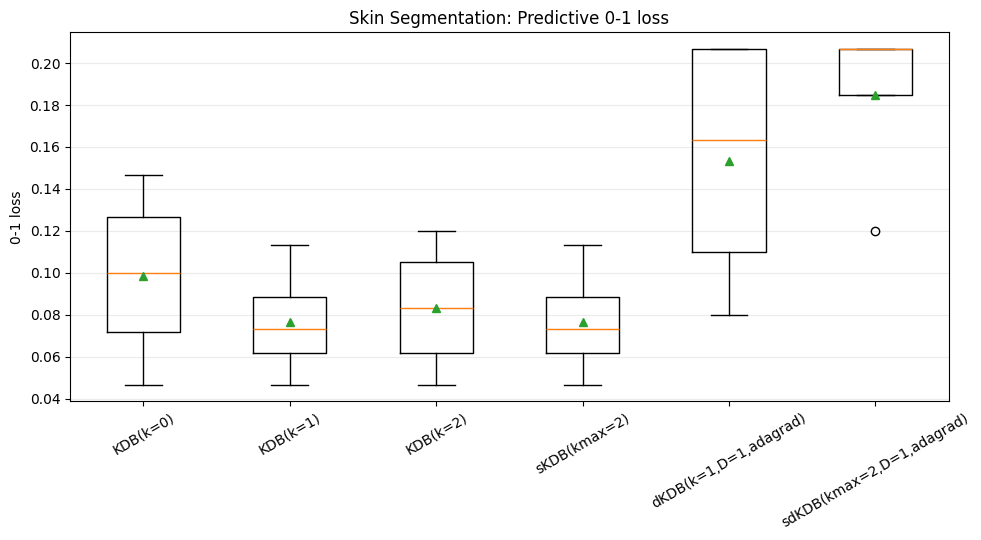

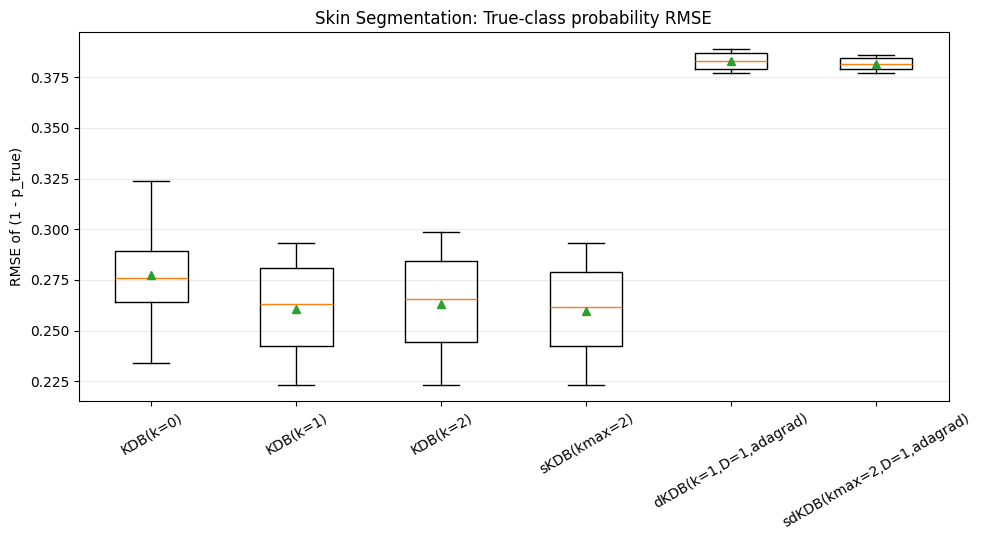

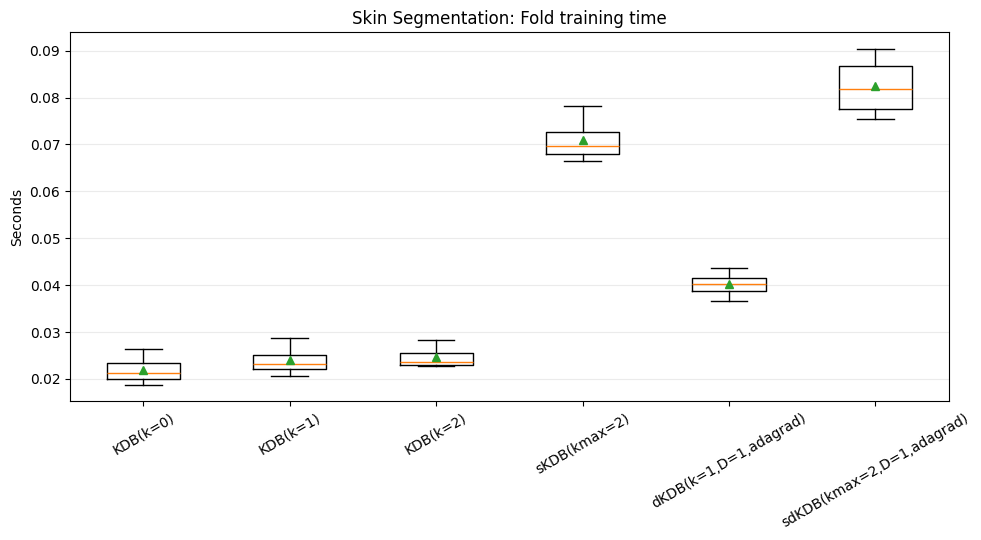

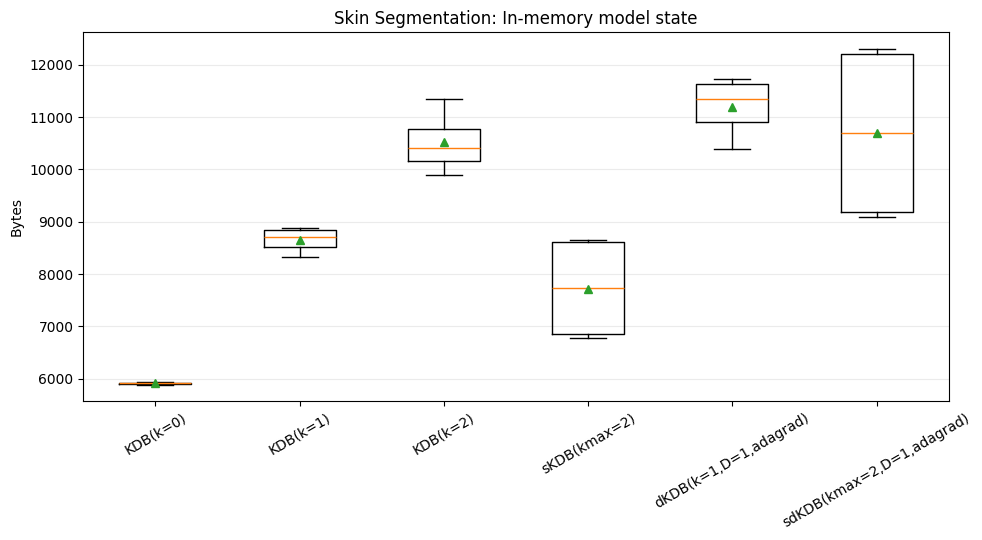

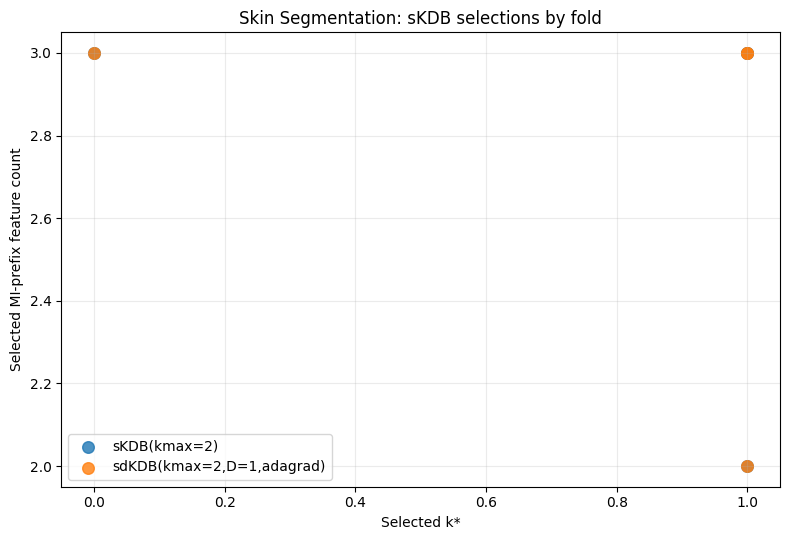

Running MiniBooNE smoke benchmark on 200 rows


,dataset,model,zero_one_loss_mean,zero_one_loss_std,rmse_true_class_probability_mean,rmse_true_class_probability_std,roc_auc_mean,roc_auc_std,preprocessing_seconds_mean,preprocessing_seconds_std,learner_training_seconds_mean,learner_training_seconds_std,total_training_seconds_mean,total_training_seconds_std,learner_passes_mean,learner_passes_std,learner_rows_processed_mean,learner_rows_processed_std,model_state_bytes_mean,model_state_bytes_std,selected_k_mean,selected_k_std,selected_feature_count_mean,selected_feature_count_std,discriminative_iterations_mean,discriminative_iterations_std,discriminative_updates_mean,discriminative_updates_std
0,MiniBooNE,KDB(k=0),0.1200,0.024495,0.323678,0.032317,NaN,NaN,0.270379,0.06493,0.003275,0.000532,0.273655,0.064994,1.0,0.0,100.0,0.0,34176.0,45.254834,0.00,0.0,50.0,0.000000,0.0,0.0,0.0,0.0
1,MiniBooNE,KDB(k=1),0.1375,0.015000,0.340799,0.020865,NaN,NaN,0.270379,0.06493,0.052013,0.005188,0.322392,0.068018,2.0,0.0,200.0,0.0,73781.0,3004.551214,1.00,0.0,50.0,0.000000,0.0,0.0,0.0,0.0
2,MiniBooNE,KDB(k=2),0.1375,0.005000,0.342469,0.008548,NaN,NaN,0.270379,0.06493,0.067692,0.015969,0.338071,0.080501,2.0,0.0,200.0,0.0,143719.0,14985.972997,2.00,0.0,50.0,0.000000,0.0,0.0,0.0,0.0
3,MiniBooNE,sKDB(kmax=2),0.1375,0.017078,0.351946,0.022359,NaN,NaN,0.270379,0.06493,0.546416,0.018217,0.816795,0.079735,3.0,0.0,300.0,0.0,59734.0,31115.517072,1.75,0.5,21.0,10.739336,0.0,0.0,0.0,0.0
4,MiniBooNE,"dKDB(k=1,D=1,adagrad)",0.1550,0.020817,0.340311,0.014621,NaN,NaN,0.270379,0.06493,0.185829,0.002279,0.456208,0.064817,3.0,0.0,300.0,0.0,111297.0,7041.654351,1.00,0.0,50.0,0.000000,1.0,0.0,100.0,0.0
5,MiniBooNE,"sdKDB(kmax=2,D=1,adagrad)",0.1650,0.059722,0.363974,0.044166,NaN,NaN,0.270379,0.06493,0.727727,0.169707,0.998106,0.154995,4.0,0.0,400.0,0.0,91316.0,49580.448458,1.75,0.5,21.0,10.739336,1.0,0.0,100.0,0.0


,dataset,model,implementation,round,fold,train_rows,test_rows,n_classes,zero_one_loss,rmse_true_class_probability,roc_auc,preprocessing_seconds,learner_training_seconds,total_training_seconds,learner_passes,learner_rows_processed,preprocessing_fit_rows,model_state_bytes,k,kmax,selected_k,selected_feature_count,selected_features,discriminative_iterations,discriminative_updates,optimizer
0,MiniBooNE,KDB(k=0),KDB,1,1,100,100,2,0.12,0.319802,NaN,0.259055,0.002991,0.262046,1,100,100,34176,0.0,NaN,0,50,"[""ParticleID_0"", ""ParticleID_1"", ""ParticleID_2...",0,0,None
1,MiniBooNE,KDB(k=1),KDB,1,1,100,100,2,0.12,0.321708,NaN,0.259055,0.055381,0.314436,2,200,100,75901,1.0,NaN,1,50,"[""ParticleID_25"", ""ParticleID_2"", ""ParticleID_...",0,0,None
2,MiniBooNE,KDB(k=2),KDB,1,1,100,100,2,0.14,0.352847,NaN,0.259055,0.060613,0.319668,2,200,100,159901,2.0,NaN,2,50,"[""ParticleID_25"", ""ParticleID_2"", ""ParticleID_...",0,0,None
3,MiniBooNE,sKDB(kmax=2),sKDB,1,1,100,100,2,0.14,0.352847,NaN,0.259055,0.548625,0.807679,3,300,100,81142,NaN,2.0,2,28,"[""ParticleID_25"", ""ParticleID_2"", ""ParticleID_...",0,0,None
4,MiniBooNE,"dKDB(k=1,D=1,adagrad)",dKDB,1,1,100,100,2,0.15,0.343896,NaN,0.259055,0.182529,0.441583,3,300,100,116249,1.0,NaN,1,50,"[""ParticleID_25"", ""ParticleID_2"", ""ParticleID_...",1,100,adagrad
5,MiniBooNE,"sdKDB(kmax=2,D=1,adagrad)",sdKDB (experimental/unpublished),1,1,100,100,2,0.11,0.345655,NaN,0.259055,0.839520,1.098575,4,400,100,126006,NaN,2.0,2,28,"[""ParticleID_25"", ""ParticleID_2"", ""ParticleID_...",1,100,adagrad
6,MiniBooNE,KDB(k=0),KDB,1,2,100,100,2,0.15,0.353164,NaN,0.364884,0.003497,0.368381,1,100,100,34144,0.0,NaN,0,50,"[""ParticleID_0"", ""ParticleID_1"", ""ParticleID_2...",0,0,None
7,MiniBooNE,KDB(k=1),KDB,1,2,100,100,2,0.15,0.354506,NaN,0.364884,0.055929,0.420814,2,200,100,76813,1.0,NaN,1,50,"[""ParticleID_0"", ""ParticleID_2"", ""ParticleID_1...",0,0,None
8,MiniBooNE,KDB(k=2),KDB,1,2,100,100,2,0.14,0.341728,NaN,0.364884,0.091571,0.456456,2,200,100,151413,2.0,NaN,2,50,"[""ParticleID_0"", ""ParticleID_2"", ""ParticleID_1...",0,0,None
9,MiniBooNE,sKDB(kmax=2),sKDB,1,2,100,100,2,0.13,0.335006,NaN,0.364884,0.567290,0.932174,3,300,100,75454,NaN,2.0,2,26,"[""ParticleID_0"", ""ParticleID_2"", ""ParticleID_1...",0,0,None


,dataset,model,round,fold,stage,pass_number,rows_processed,seconds
0,MiniBooNE,KDB(k=0),1,1,naive_bayes_parameters,1,100,0.002683
1,MiniBooNE,KDB(k=1),1,1,kdb_structure_mi_cmi,1,100,0.002792
2,MiniBooNE,KDB(k=1),1,1,kdb_parameters,2,100,0.023873
3,MiniBooNE,KDB(k=2),1,1,kdb_structure_mi_cmi,1,100,0.001266
4,MiniBooNE,KDB(k=2),1,1,kdb_parameters,2,100,0.033504
5,MiniBooNE,sKDB(kmax=2),1,1,kdb_structure_mi_cmi,1,100,0.004032
6,MiniBooNE,sKDB(kmax=2),1,1,kdb_parameters,2,100,0.034887
7,MiniBooNE,sKDB(kmax=2),1,1,skdb_incremental_loocv,3,100,0.475632
8,MiniBooNE,"dKDB(k=1,D=1,adagrad)",1,1,kdb_structure_mi_cmi,1,100,0.001107
9,MiniBooNE,"dKDB(k=1,D=1,adagrad)",1,1,kdb_parameters,2,100,0.024998


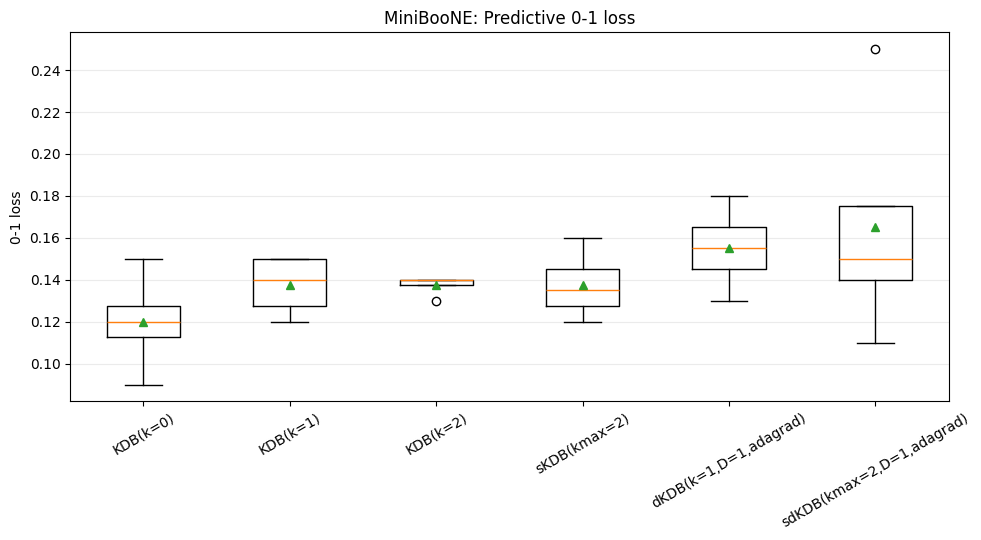

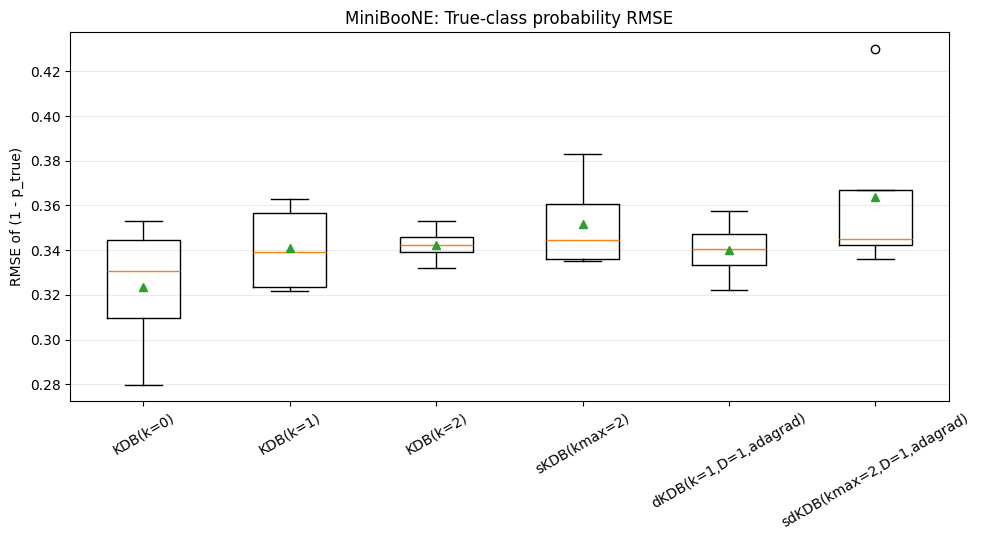

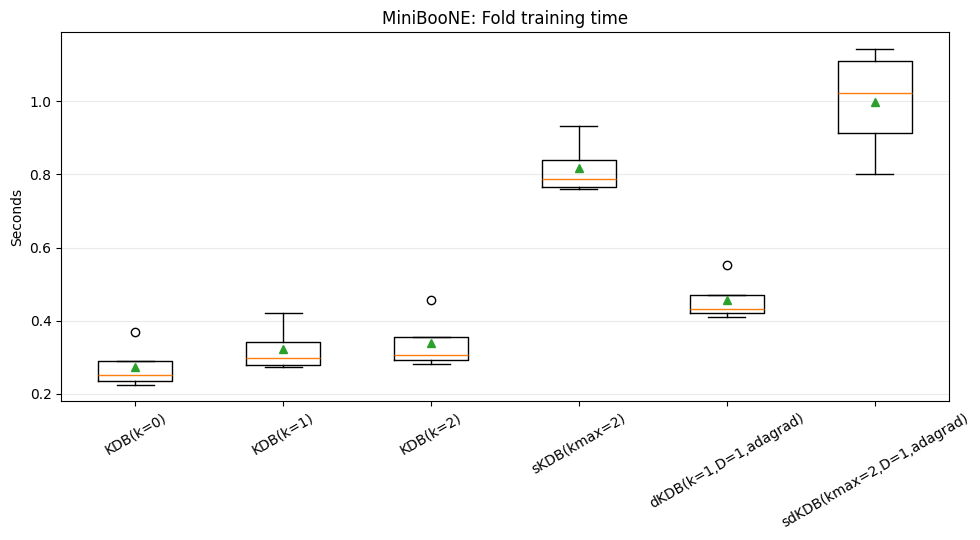

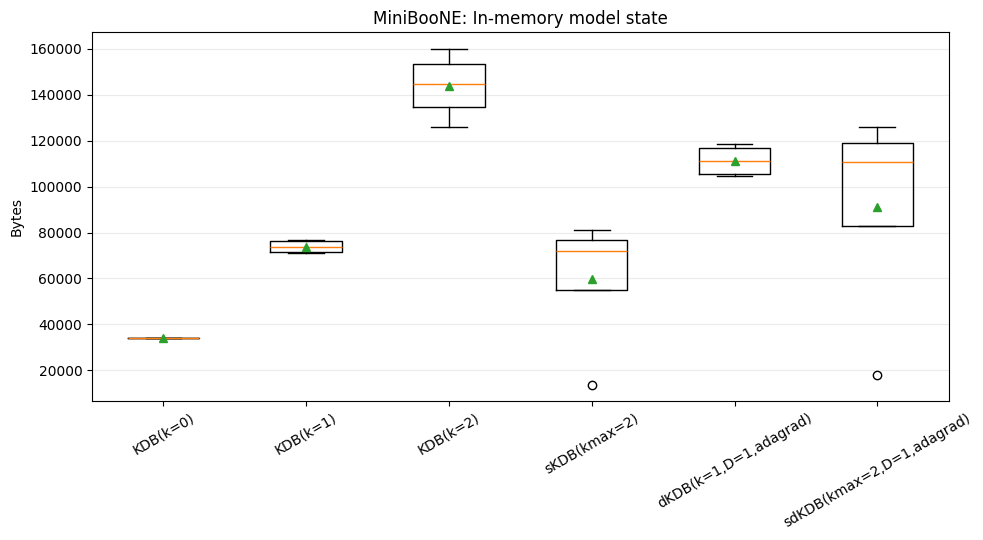

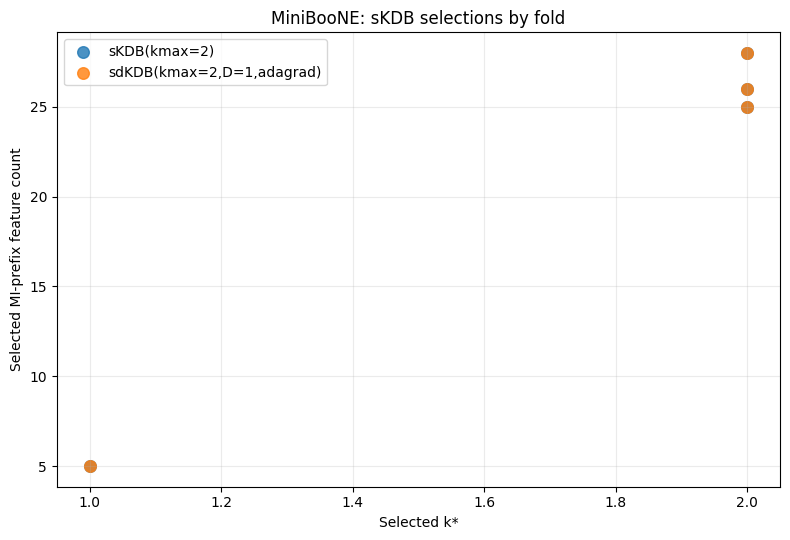

In [15]:
benchmark_results = {}
if RUN_SMOKE_EXPERIMENTS:
    for dataset_name, max_rows in SMOKE_ROWS.items():
        print("=" * 100)
        print(f"Running {dataset_name} smoke benchmark on {max_rows} rows")
        result = run_smoke_benchmark(
            dataset_name, max_rows=max_rows, k_values=K_VALUES, kmax=KMAX,
            discriminative_passes=DISCRIMINATIVE_PASSES, optimizer=OPTIMIZER,
            learning_rate=LEARNING_RATE, config=CV_CONFIG,
        )
        benchmark_results[dataset_name] = result
        display(result.summary)
        display(result.fold_results)
        display(result.pass_audit)
        dataset_output = OUTPUT_DIR / dataset_name if SAVE_OUTPUTS else None
        if SAVE_OUTPUTS:
            result.save(dataset_output, prefix="benchmark")
        plot_evaluation(result, output_dir=dataset_output, prefix="benchmark")
        plt.show()
else:
    print("Smoke experiments disabled.")


## 13. Direct comparison across configured k values

These graphs isolate base KDB, showing how 0-1 loss and true-class RMSE change over `k=0,1,2,...`.

,k,loss_mean,loss_std,rmse_mean,rmse_std,dataset
0,0.0,0.098333,0.044012,0.277403,0.036846,Skin Segmentation
1,1.0,0.076667,0.028021,0.260557,0.030813,Skin Segmentation
2,2.0,0.083333,0.032886,0.263282,0.032867,Skin Segmentation


,k,loss_mean,loss_std,rmse_mean,rmse_std,dataset
0,0.0,0.1200,0.024495,0.323678,0.032317,MiniBooNE
1,1.0,0.1375,0.015000,0.340799,0.020865,MiniBooNE
2,2.0,0.1375,0.005000,0.342469,0.008548,MiniBooNE


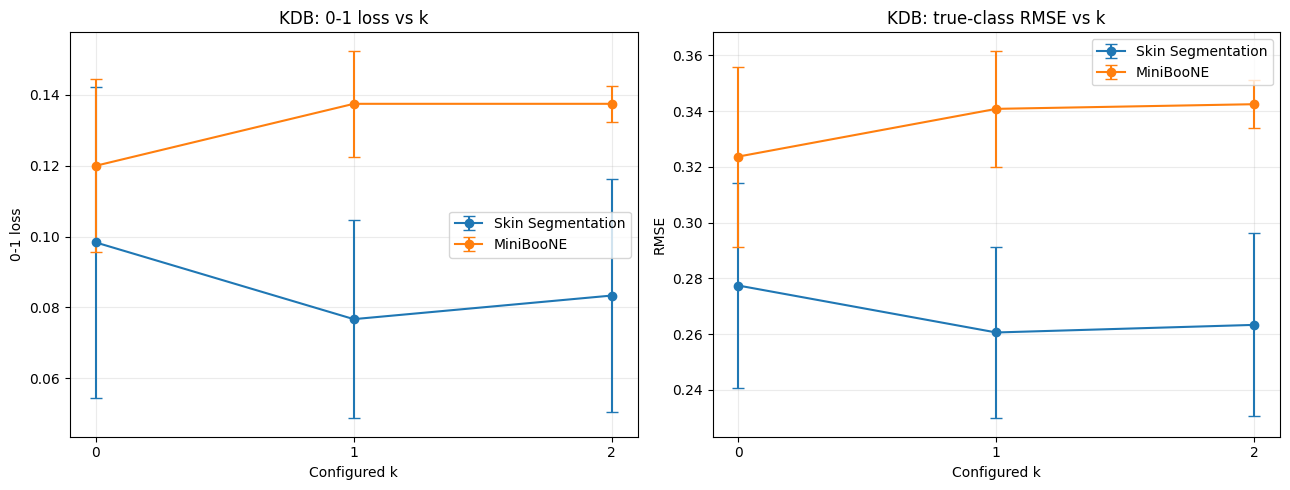

In [16]:
if benchmark_results:
    figure, axes = plt.subplots(1, 2, figsize=(13, 5))
    for dataset_name, result in benchmark_results.items():
        kdb_rows = result.fold_results[result.fold_results["model"].str.match(r"^KDB\(k=\d+\)$")]
        aggregate = kdb_rows.groupby("k").agg(
            loss_mean=("zero_one_loss", "mean"), loss_std=("zero_one_loss", "std"),
            rmse_mean=("rmse_true_class_probability", "mean"), rmse_std=("rmse_true_class_probability", "std"),
        ).reset_index()
        display(aggregate.assign(dataset=dataset_name))
        axes[0].errorbar(aggregate["k"], aggregate["loss_mean"], yerr=aggregate["loss_std"], marker="o", capsize=4, label=dataset_name)
        axes[1].errorbar(aggregate["k"], aggregate["rmse_mean"], yerr=aggregate["rmse_std"], marker="o", capsize=4, label=dataset_name)
    axes[0].set(title="KDB: 0-1 loss vs k", xlabel="Configured k", ylabel="0-1 loss")
    axes[1].set(title="KDB: true-class RMSE vs k", xlabel="Configured k", ylabel="RMSE")
    for axis in axes:
        axis.set_xticks(K_VALUES); axis.grid(alpha=0.25); axis.legend()
    figure.tight_layout(); plt.show()


## 14. Final requirement audit

| Requirement | Notebook location |
|---|---|
| One reusable implementation, no Skin/Mini duplication | Sections 3–9 define once; Section 12 reuses it |
| KDB base and true one-pass k=0 | Section 5 plus equality/structure test |
| Published third-pass sKDB | Section 6, returning k* and feature count |
| Fixed-Θ weighted-BN dKDB | Section 7 plus Θ-checksum test |
| Experimental/unpublished sdKDB | Sections 1 and 7; selection then identical weighting only |
| Existing in-memory fold-fitted preprocessing | Sections 3 and 8 plus leakage test |
| Multiclass 2×2 evaluator and complete audit fields | Section 8 |
| All requested tests | Section 10 |
| Skin and MiniBooNE smoke only | Sections 9, 11 and 12 |
| Preserve/exclude RF/XGB/HT; stop before large experiments | Explicitly enforced by scope/defaults |

### Explicit assumptions

- Weighted-BN uses fixed generative log-Θ multiplied by learned weights, corresponding to Fupla's weighted discriminative semantics.
- sdKDB is not presented as separately published: it means only `sKDB selection → dKDB weighting`.
- If no prefix improves the prior-only score, Fupla-compatible selection returns zero features and retains initialized `kmax` (then operationally irrelevant).
- Model memory is recursive live Python state, not process RSS.
- Smoke figures verify execution/accounting and are not final scientific results.